Part 1: Data Collection & Cleaning

In [1]:
import pandas as pd
import numpy as np

In [2]:
ecom = pd.read_csv('E Commerce Dataset.csv')
ecom.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [3]:
ecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [4]:
# Remove duplicate rows
ecom.drop_duplicates(inplace=True)

In [5]:
# Convert appropriate columns to 'category' dtype
ecom['CityTier'] = ecom['CityTier'].astype('category')
ecom['NumberOfAddress'] = ecom['NumberOfAddress'].astype('category')

In [6]:
# Drop unnecessary columns
ecom = ecom.drop(columns=['CustomerID'])

In [7]:
# Check again
ecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Churn                        5630 non-null   int64   
 1   Tenure                       5366 non-null   float64 
 2   PreferredLoginDevice         5630 non-null   object  
 3   CityTier                     5630 non-null   category
 4   WarehouseToHome              5379 non-null   float64 
 5   PreferredPaymentMode         5630 non-null   object  
 6   Gender                       5630 non-null   object  
 7   HourSpendOnApp               5375 non-null   float64 
 8   NumberOfDeviceRegistered     5630 non-null   int64   
 9   PreferedOrderCat             5630 non-null   object  
 10  SatisfactionScore            5630 non-null   int64   
 11  MaritalStatus                5630 non-null   object  
 12  NumberOfAddress              5630 non-null   category
 13  Com

In [8]:
ecom.isnull().sum()

Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [9]:
ecom.describe()

,Churn,Tenure,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5366.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,0.168384,10.189899,15.639896,2.931535,3.688988,3.066785,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,0.374240,8.557241,8.531475,0.721926,1.023999,1.380194,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,0.000000,0.000000,5.000000,0.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,2.000000,9.000000,2.000000,3.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,0.000000,9.000000,14.000000,3.000000,4.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,0.000000,16.000000,20.000000,3.000000,4.000000,4.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,1.000000,61.000000,127.000000,5.000000,6.000000,5.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


In [10]:
# Impute missing values with median for numerical columns
for col in ecom.columns:
    if ecom[col].isnull().sum() > 0:
        ecom[col].fillna(ecom[col].median(), inplace=True)
ecom.isnull().sum()

C:\Users\richb\AppData\Local\Temp\ipykernel_4924\1486986390.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ecom[col].fillna(ecom[col].median(), inplace=True)
C:\Users\richb\AppData\Local\Temp\ipykernel_4924\1486986390.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

Part 2: EDA - Exploratory Analysis

In [11]:
ecom['Churn'].value_counts(normalize=True)

Churn
0    0.831616
1    0.168384
Name: proportion, dtype: float64

<Axes: >

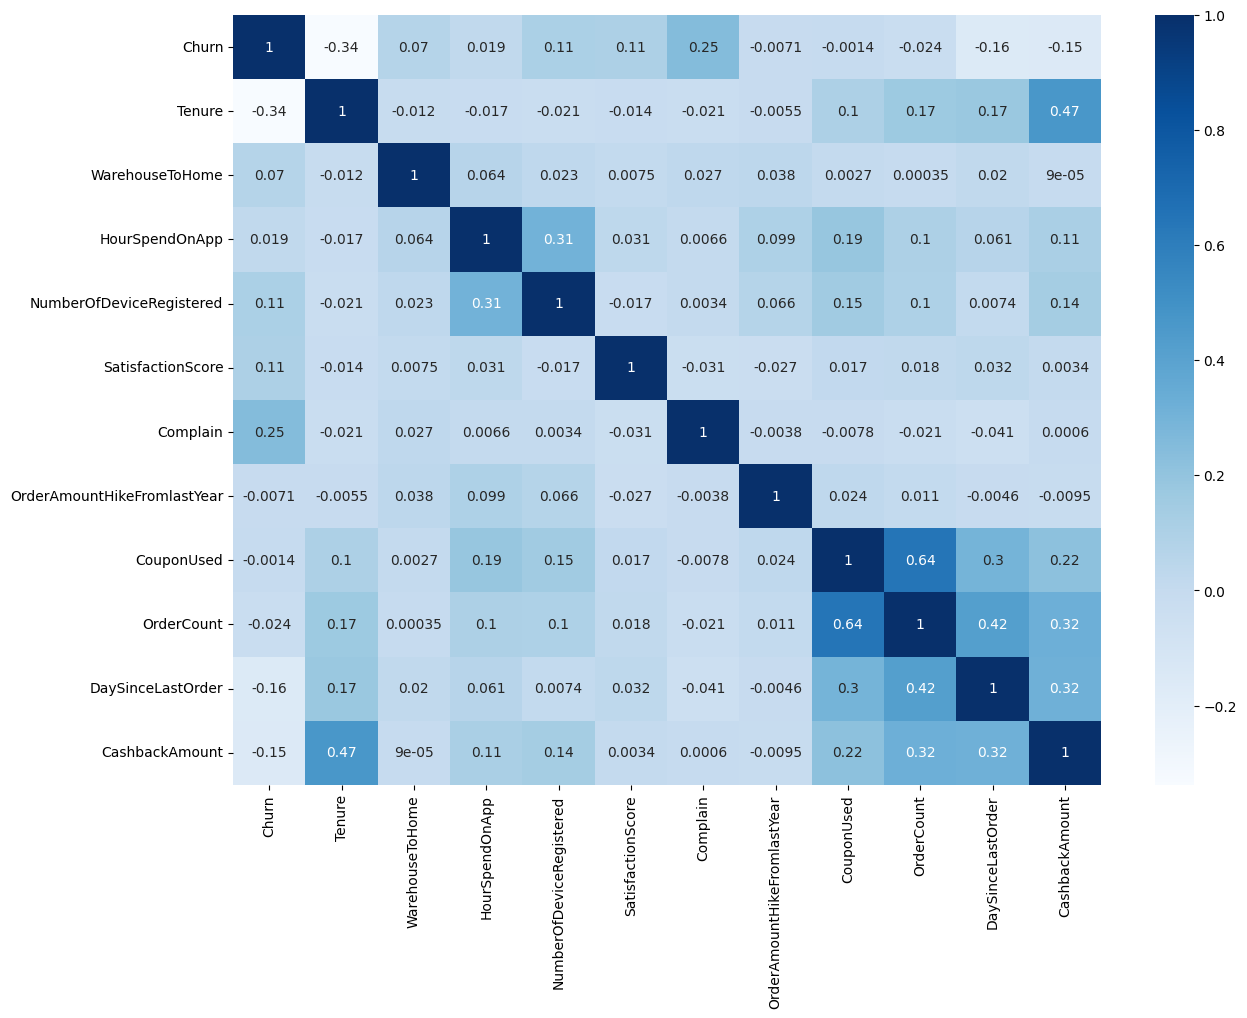

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
sns.heatmap(ecom.select_dtypes(include=['int64', 'float64']).corr(),
            cmap="Blues",
            annot=True)


In [13]:
# Obvious features: 
# Tenure, NumberOfDeviceRegistered, SatisfactionScore, 
# Complain, DaySinceLastOrder, CashbackAmount

Text(0, 0.5, 'Count')

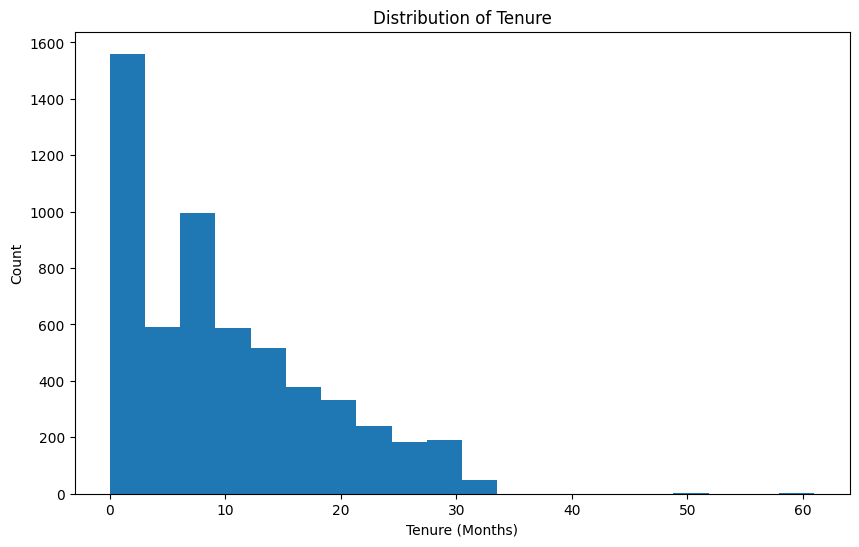

In [14]:
plt.figure(figsize=(10,6))
plt.hist(ecom['Tenure'].dropna(), bins=20)
plt.title("Distribution of Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")

Text(0, 0.5, 'Tenure')

<Figure size 1000x600 with 0 Axes>

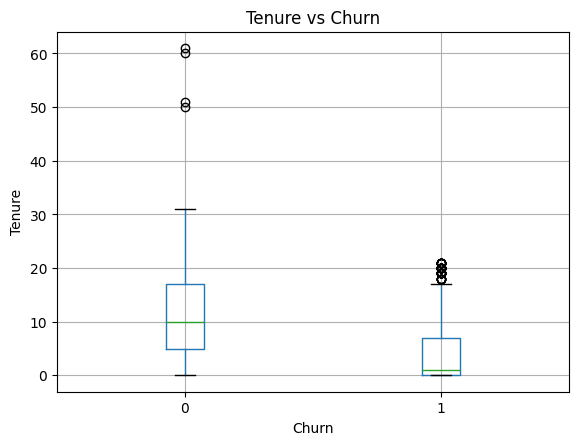

In [15]:
plt.figure(figsize=(10,6))
ecom.boxplot(column='Tenure', by='Churn')
plt.title("Tenure vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure")

Text(0, 0.5, 'Count')

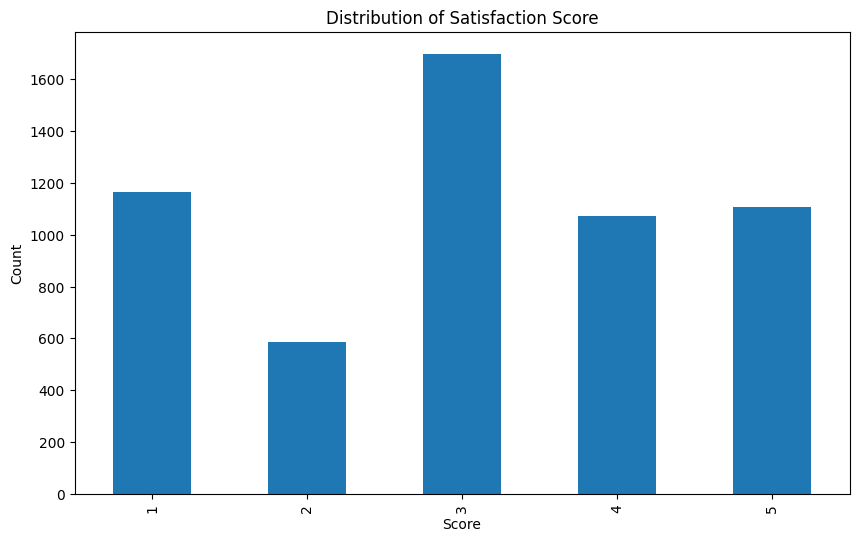

In [16]:
plt.figure(figsize=(10,6))
ecom['SatisfactionScore'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Satisfaction Score")
plt.xlabel("Score")
plt.ylabel("Count")

Text(0, 0.5, 'Average Score')

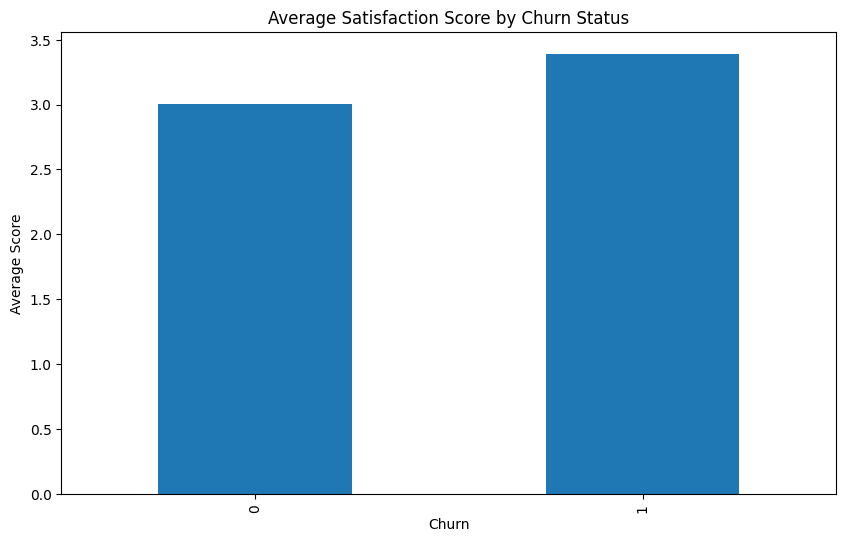

In [17]:
plt.figure(figsize=(10,6))
ecom.groupby('Churn')['SatisfactionScore'].mean().plot(kind='bar')
plt.title("Average Satisfaction Score by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Score")

Text(0, 0.5, 'Count')

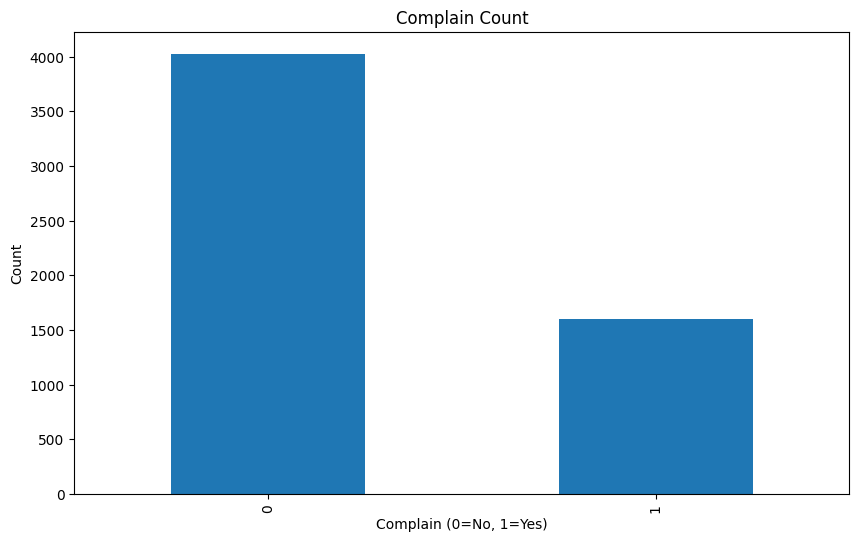

In [18]:
plt.figure(figsize=(10,6))
ecom['Complain'].value_counts().sort_index().plot(kind='bar')
plt.title("Complain Count")
plt.xlabel("Complain (0=No, 1=Yes)")
plt.ylabel("Count")

Text(0, 0.5, 'Churn Rate')

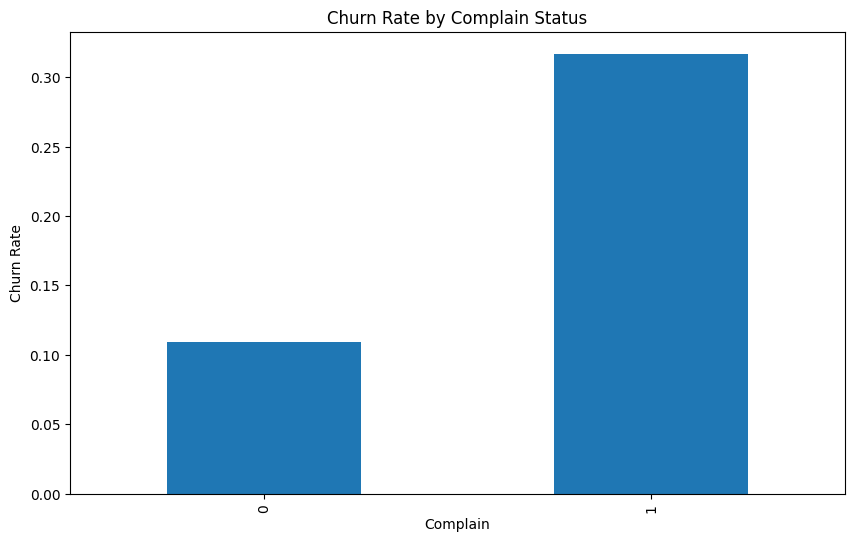

In [19]:
plt.figure(figsize=(10,6))
ecom.groupby('Complain')['Churn'].mean().plot(kind='bar')
plt.title("Churn Rate by Complain Status")
plt.xlabel("Complain")
plt.ylabel("Churn Rate")

Text(0, 0.5, 'Count')

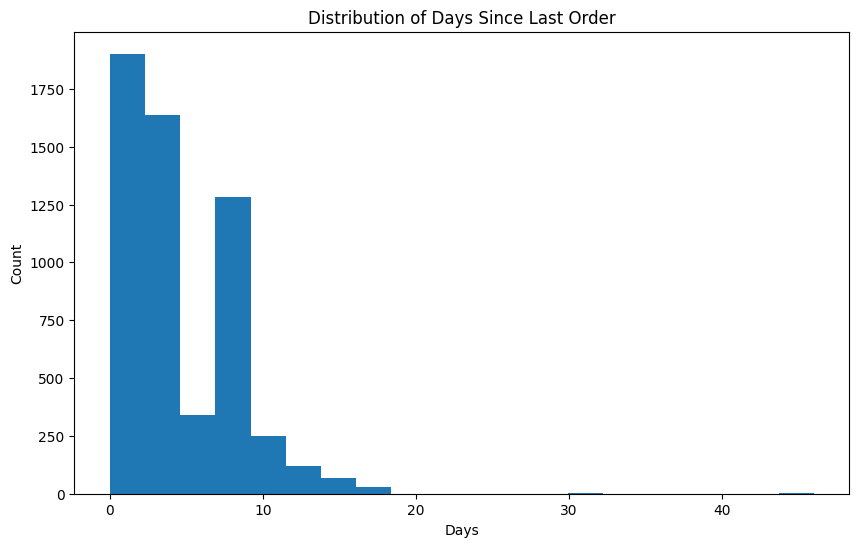

In [20]:
plt.figure(figsize=(10,6))
plt.hist(ecom['DaySinceLastOrder'].dropna(), bins=20)
plt.title("Distribution of Days Since Last Order")
plt.xlabel("Days")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

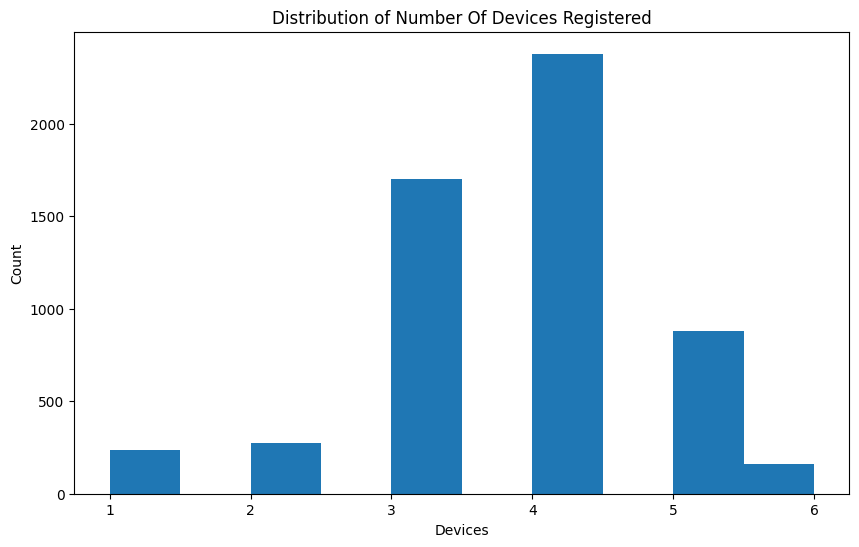

In [21]:
plt.figure(figsize=(10,6))
plt.hist(ecom['NumberOfDeviceRegistered'], bins=10)
plt.title("Distribution of Number Of Devices Registered")
plt.xlabel("Devices")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

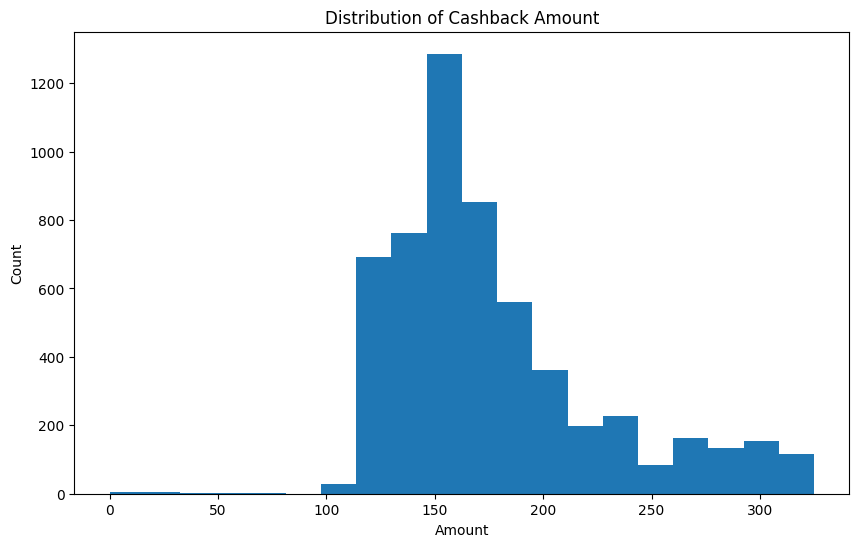

In [22]:
plt.figure(figsize=(10,6))
plt.hist(ecom['CashbackAmount'], bins=20)
plt.title("Distribution of Cashback Amount")
plt.xlabel("Amount")
plt.ylabel("Count")

Part 3: Model Building

In [23]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Preprocessor: OneHotEncoder and StandardScaling
categorical_cols = ['PreferredLoginDevice', 'PreferredPaymentMode',
                    'Gender', 'PreferedOrderCat', 'MaritalStatus']

numeric_cols = [col for col in ecom.columns if col not in categorical_cols + ['Churn']]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

In [24]:
# Models with class_weight
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SVM": SVC(probability=True, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1)
        

}

In [25]:
# Train/Test split
X = ecom.drop(columns=['Churn'])
y = ecom['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,          # 80% train / 20% test
    random_state=42,        # keep random state consistent
    stratify=y              # Keep the churn ratio consistent
)

In [26]:
trained_models = {}

# Training each model
for name, model in models.items():
    clf = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42)),   # SMOTE to handle class imbalance
        ('model', model)
    ])
    
    clf.fit(X_train, y_train)
    trained_models[name] = clf

    y_pred = clf.predict(X_test)

    print("====================================")
    print(f"====== {name} ======")
    print(classification_report(y_test, y_pred))


====== Logistic Regression ======
              precision    recall  f1-score   support

           0       0.96      0.79      0.87       936
           1       0.45      0.84      0.58       190

    accuracy                           0.80      1126
   macro avg       0.70      0.81      0.72      1126
weighted avg       0.87      0.80      0.82      1126

====== SVM ======
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       936
           1       0.70      0.89      0.79       190

    accuracy                           0.92      1126
   macro avg       0.84      0.91      0.87      1126
weighted avg       0.93      0.92      0.92      1126

====== Decision Tree ======
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       936
           1       0.84      0.88      0.86       190

    accuracy                           0.95      1126
   macro avg       0.91      0.92      0.91     

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 3) Identify numeric vs categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical:", list(categorical_cols))
print("Numeric:", list(numeric_cols))

# 4) Preprocessing for numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# 5) Define Random Forest model
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# 6) Build full pipeline: preprocess -> model
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf_clf)
])

# 7) Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 8) Fit model
model.fit(X_train, y_train)

# 9) Evaluate
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Classification report:")
print(classification_report(y_test, y_pred))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

Categorical: ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
Numeric: ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
Classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       936
           1       1.00      0.87      0.93       190

    accuracy                           0.98      1126
   macro avg       0.99      0.94      0.96      1126
weighted avg       0.98      0.98      0.98      1126

Confusion matrix:
[[936   0]
 [ 24 166]]
ROC AUC: 0.9988613360323887


In [28]:
from xgboost import XGBClassifier

# 5) XGBoost model
xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# 6) XGBoost pipeline
xgb_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("xgb", xgb_clf)
])

# 7) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 8) Fit model
xgb_model.fit(X_train, y_train)

# 9) Evaluate
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost Classification Report ===")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))


=== XGBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       936
           1       0.86      0.74      0.80       190

    accuracy                           0.94      1126
   macro avg       0.90      0.86      0.88      1126
weighted avg       0.93      0.94      0.93      1126

Confusion Matrix:
[[913  23]
 [ 49 141]]
ROC AUC: 0.9714518668466037


Part 4: Model Evaluation & Interpretation

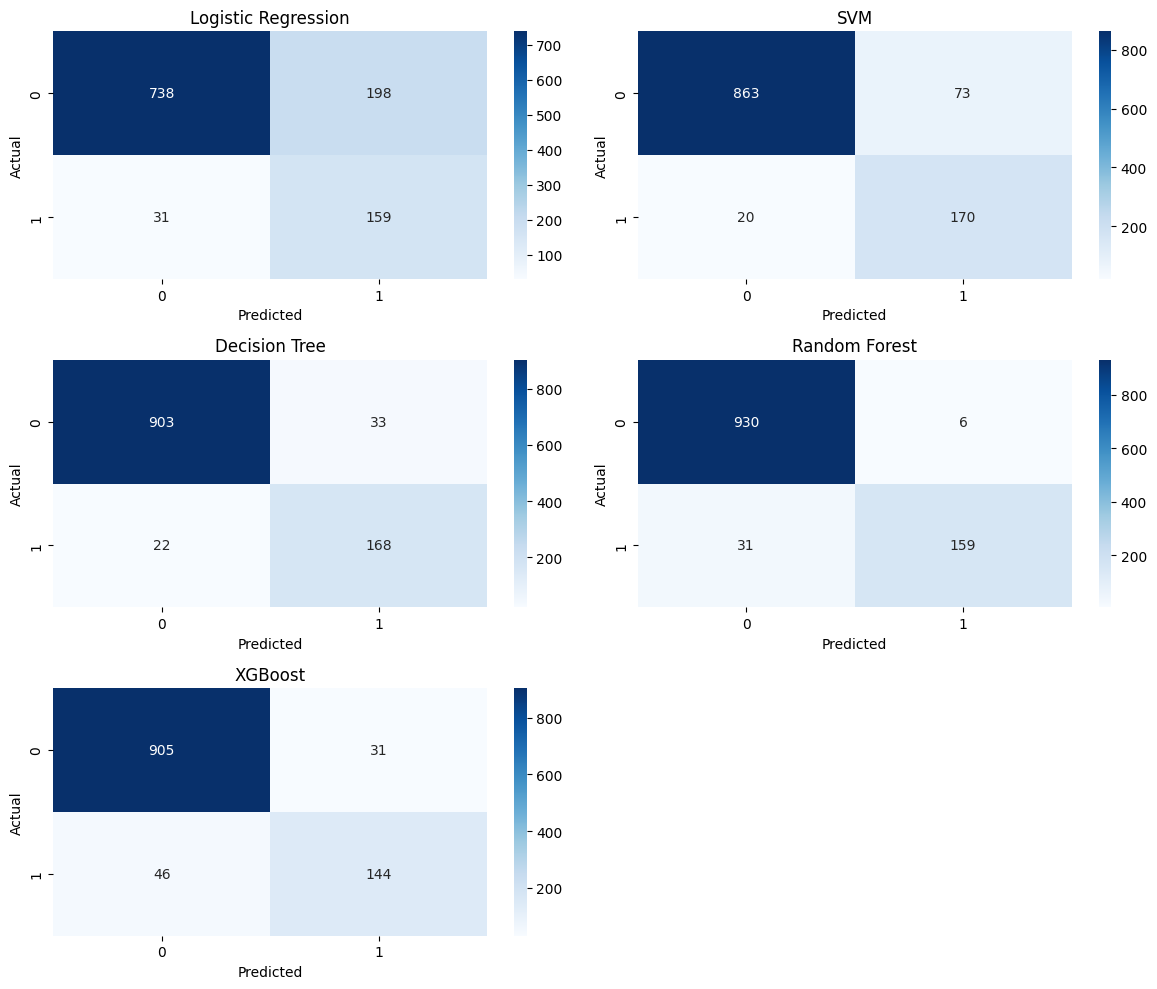

In [29]:
# Confusion Matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(12, 10))

for i, (name, clf) in enumerate(trained_models.items(), 1):
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(3, 2, i)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

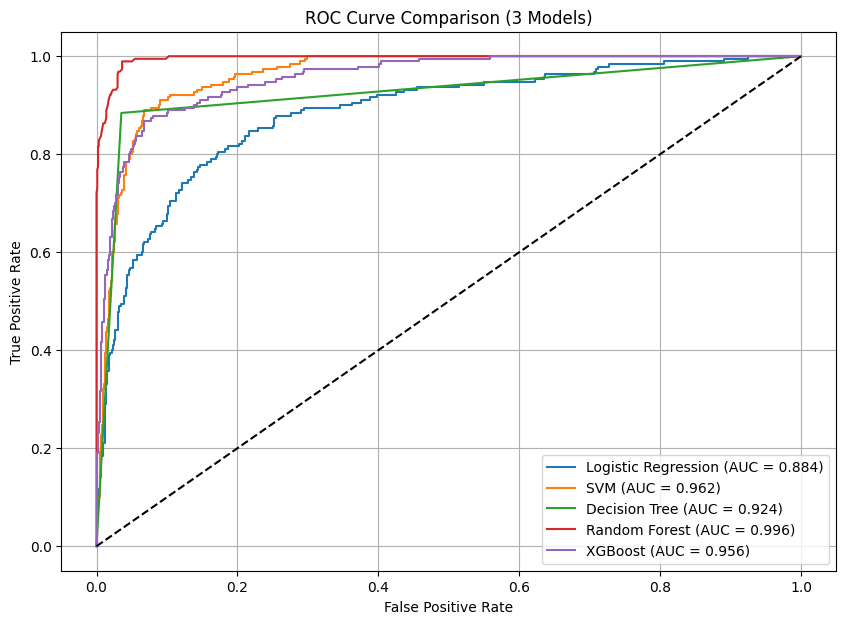

In [30]:
# ROC Curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for name, clf in trained_models.items():
    y_proba = clf.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison (3 Models)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [31]:
# Logistic Regression — Top 10 Features
log_features = trained_models["Logistic Regression"].named_steps['preprocess'].get_feature_names_out()
log_importance = trained_models["Logistic Regression"].named_steps['model'].coef_[0]

log_top10 = pd.Series(log_importance, index=log_features).reindex(
    pd.Series(abs(log_importance), index=log_features).sort_values(ascending=False).index
)[:10]

print("===== Logistic Regression Top 10 Features =====")
print(log_top10)

===== Logistic Regression Top 10 Features =====
cat__PreferedOrderCat_Others                2.434829
cat__PreferedOrderCat_Laptop & Accessory   -1.853761
num__Tenure                                -1.752881
num__CashbackAmount                        -1.003920
cat__PreferedOrderCat_Mobile Phone         -0.793831
num__Complain                               0.711588
num__NumberOfAddress                        0.659155
cat__PreferedOrderCat_Mobile               -0.640854
cat__MaritalStatus_Single                   0.533508
cat__PreferredPaymentMode_E wallet          0.512077
dtype: float64


In [32]:
# Decision Tree — Top 10 Features
dt_features = trained_models["Decision Tree"].named_steps['preprocess'].get_feature_names_out()
dt_importance = trained_models["Decision Tree"].named_steps['model'].feature_importances_

dt_top10 = pd.Series(dt_importance, index=dt_features).sort_values(ascending=False)[:10]

print("===== Decision Tree Top 10 Features =====")
print(dt_top10)

===== Decision Tree Top 10 Features =====
num__Tenure                                 0.348611
num__NumberOfAddress                        0.076821
num__SatisfactionScore                      0.060753
num__Complain                               0.060446
num__DaySinceLastOrder                      0.053975
num__CashbackAmount                         0.053921
num__WarehouseToHome                        0.041709
cat__PreferedOrderCat_Laptop & Accessory    0.035723
num__CityTier                               0.034472
cat__PreferedOrderCat_Fashion               0.032874
dtype: float64


In [33]:
from sklearn.inspection import permutation_importance

# preprocess（One-Hot + Scaling）
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

# SMOTE preprocess data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_trans, y_train)

# Training SVM
svm_model = SVC(probability=True, class_weight='balanced')
svm_model.fit(X_train_res, y_train_res)

# Permutation importance
result = permutation_importance(
    svm_model,
    X_test_trans,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1'
)

svm_importance = pd.Series(result.importances_mean, index=feature_names)
svm_top10 = svm_importance.sort_values(ascending=False).head(10)

print("===== SVM Top 10 Features =====")
print(svm_top10)

===== SVM Top 10 Features =====
num__Tenure                                 0.247921
num__Complain                               0.176133
num__NumberOfAddress                        0.107349
num__DaySinceLastOrder                      0.072945
num__CityTier                               0.070946
num__SatisfactionScore                      0.069982
num__CashbackAmount                         0.066324
num__WarehouseToHome                        0.056795
num__NumberOfDeviceRegistered               0.051540
cat__PreferedOrderCat_Laptop & Accessory    0.045926
dtype: float64


In [34]:
# Random Forest — Top 10 Features
rf_pipe = trained_models["Random Forest"]

rf_features = rf_pipe.named_steps["preprocess"].get_feature_names_out()
rf_importance = rf_pipe.named_steps["model"].feature_importances_

rf_top10 = pd.Series(rf_importance, index=rf_features).sort_values(ascending=False).head(10)

print("===== Random Forest Top 10 Features =====")
print(rf_top10)


===== Random Forest Top 10 Features =====
num__Tenure                         0.203647
num__CashbackAmount                 0.061972
num__Complain                       0.056446
num__DaySinceLastOrder              0.054286
num__NumberOfAddress                0.048507
num__WarehouseToHome                0.045371
num__SatisfactionScore              0.044541
cat__MaritalStatus_Single           0.040921
num__NumberOfDeviceRegistered       0.039780
num__OrderAmountHikeFromlastYear    0.039466
dtype: float64


In [35]:
# XGBoost — Top 10 Features
xgb_pipe = trained_models["XGBoost"]

xgb_features = xgb_pipe.named_steps["preprocess"].get_feature_names_out()
xgb_importance = xgb_pipe.named_steps["model"].feature_importances_

xgb_top10 = pd.Series(xgb_importance, index=xgb_features).sort_values(ascending=False).head(10)

print("===== XGBoost Top 10 Features =====")
print(xgb_top10)


===== XGBoost Top 10 Features =====
num__Tenure                                 0.106197
cat__MaritalStatus_Single                   0.088098
cat__MaritalStatus_Married                  0.072036
num__Complain                               0.061943
cat__PreferedOrderCat_Laptop & Accessory    0.057380
cat__PreferedOrderCat_Mobile                0.038987
num__NumberOfDeviceRegistered               0.037817
cat__MaritalStatus_Divorced                 0.032795
cat__PreferredPaymentMode_Debit Card        0.031947
cat__PreferredPaymentMode_Credit Card       0.029104
dtype: float32
